# Phase 8: commerce analytics

Use the curated data from phase 5 to answer business questions. Reusable calculations live in `src/analytics/metrics.py`; the dashboard uses the same functions. Database and warehouse checks are recorded separately by phases 6?7.

**Population:** delivered orders by default. Revenue means recorded item price, excluding freight; payment means recorded payment components, including freight. Neither is net revenue after refunds or fees. All timestamps are source-local and retrospective.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'plan.md').is_file() and (p / 'src').is_dir())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
from src.analytics import metrics
from src.analytics.reports import load_data, build_reports

data = load_data(root / 'data/processed')
statuses = ['delivered']  # Set to None to include all statuses.
orders = metrics.select_orders(data['orders'], statuses=statuses)
reports = build_reports(data, statuses=statuses)
print(f'{len(orders):,} selected orders; {orders.customer_unique_id.nunique():,} customers')
display(reports['overview'].T.rename(columns={0: 'value'}))
display(data['orders'].groupby('order_status').agg(orders=('order_id', 'size'), payments=('total_payment', 'sum')))

96,478 selected orders; 93,358 customers


,value
order_count,9.647800e+04
customer_count,9.335800e+04
item_revenue,1.322150e+07
freight,2.198276e+06
payments,1.542246e+07
average_order_value,1.598564e+02
known_payment_orders,9.647700e+04
average_review_score,4.155908e+00
reviewed_orders,9.583200e+04
late_delivery_rate,6.773090e-02


,orders,payments
order_status,,
approved,2,241.08
canceled,625,143255.60
created,5,688.10
delivered,96478,15422461.77
invoiced,314,69137.99
processing,301,69394.11
shipped,1107,177213.96
unavailable,609,126479.51


## Sales and products

How did recorded revenue, order count, and average payment change by purchase month? Which categories and products contributed most? Partial boundary months are retained; monthly growth compares consecutive observed months. A product/order review is counted once even when several units were purchased.

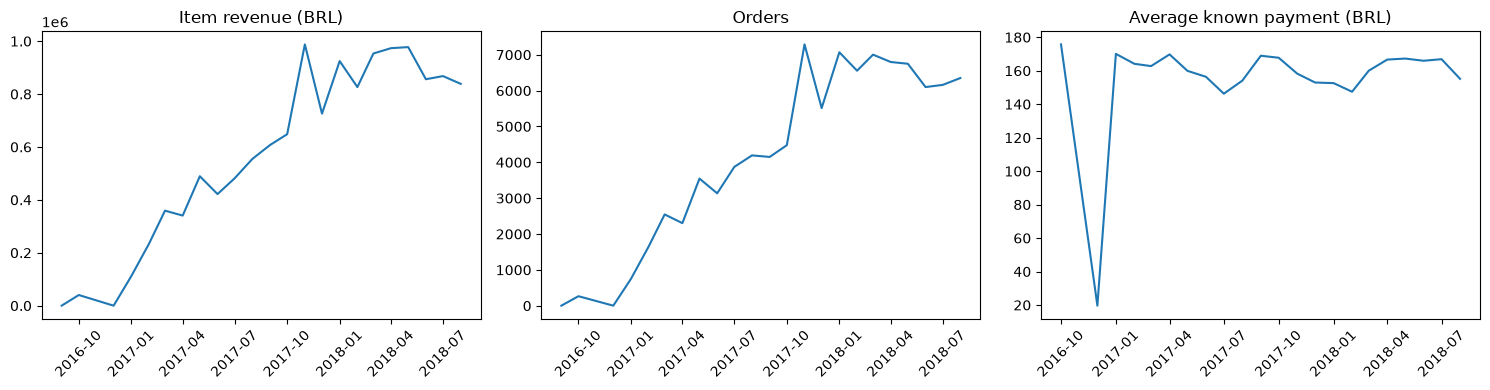

,month,order_count,customer_count,average_order_value,reviewed_orders,average_review_score,item_revenue,freight,payments,order_growth_rate,running_item_revenue
0,2016-09-01,1,1,NaN,1,1.000000,134.97,8.49,NaN,NaN,134.97
1,2016-10-01,265,262,175.723434,262,4.011450,40325.11,6165.55,46566.71,264.000000,40460.08
2,2016-12-01,1,1,19.620000,1,5.000000,10.90,8.72,19.62,-0.996226,40470.98
3,2017-01-01,750,718,170.060893,741,4.198381,111798.36,15684.01,127545.67,749.000000,152269.34
4,2017-02-01,1653,1630,164.125015,1643,4.203287,234223.40,37015.92,271298.65,1.204000,386492.74
5,2017-03-01,2546,2508,162.753099,2527,4.186783,359198.85,55132.10,414369.39,0.540230,745691.59
6,2017-04-01,2303,2274,169.757785,2290,4.135371,340669.68,50142.72,390952.18,-0.095444,1086361.27
7,2017-05-01,3546,3479,159.917296,3518,4.236498,489338.25,77513.15,567066.73,0.539731,1575699.52
8,2017-06-01,3135,3076,156.371802,3111,4.222758,421923.37,68127.00,490225.60,-0.115905,1997622.89
9,2017-07-01,3872,3802,146.282007,3842,4.259500,481604.52,84694.56,566403.93,0.235088,2479227.41


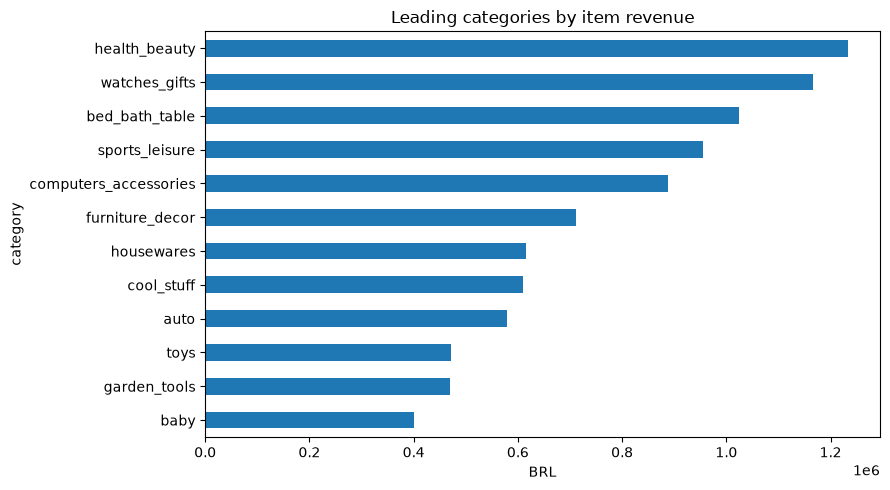

,product_id,units,order_count,category,average_price,item_revenue,average_review_score,reviewed_orders
21617,aca2eb7d00ea1a7b8ebd4e68314663af,520,425,furniture_decor,71.354423,37104.30,4.130024,423
8429,422879e10f46682990de24d770e7f83d,484,352,garden_tools,54.911612,26577.22,4.142450,351
19290,99a4788cb24856965c36a24e339b6058,477,456,bed_bath_table,88.154423,42049.66,3.933036,448
7206,389d119b48cf3043d311335e499d9c6b,390,309,garden_tools,54.709718,21336.79,4.198052,308
6926,368c6c730842d78016ad823897a372db,388,291,garden_tools,54.270103,21056.80,4.128028,289
10589,53759a2ecddad2bb87a079a1f1519f73,373,287,garden_tools,54.657373,20387.20,3.975439,285
26436,d1c427060a0f73f6b889a5c7c61f2ac4,332,313,computers_accessories,137.411325,45620.56,4.321543,311
10616,53b36df67ebb7c41585e8d54d6772e08,321,304,watches_gifts,116.681090,37454.63,4.245033,302
2734,154e7e31ebfa092203795c972e5804a6,274,262,health_beauty,22.530146,6173.26,4.375479,261
7881,3dd2a17168ec895c781a9191c1e95ad7,272,253,computers_accessories,149.936765,40782.80,4.317460,252


In [2]:
monthly = reports['monthly_sales']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column, title in zip(axes, ['item_revenue', 'order_count', 'average_order_value'],
    ['Item revenue (BRL)', 'Orders', 'Average known payment (BRL)']):
    axis.plot(monthly['month'], monthly[column])
    axis.set_title(title)
    axis.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()
display(monthly)

categories = reports['category_sales']
categories.head(12).sort_values('item_revenue').plot.barh(x='category', y='item_revenue', figsize=(9, 5), legend=False, title='Leading categories by item revenue')
plt.xlabel('BRL')
plt.tight_layout()
plt.show()
display(reports['product_sales'].head(10))

## Customer activity and retention

First purchase is the first observed order within the selected population, not guaranteed lifetime acquisition. Retention divides active customers by the cohort's original size. Observed inactive months are zero; periods beyond the dataset endpoint remain absent. RFM uses the day after the last selected purchase as its snapshot, so results do not drift with the current date.

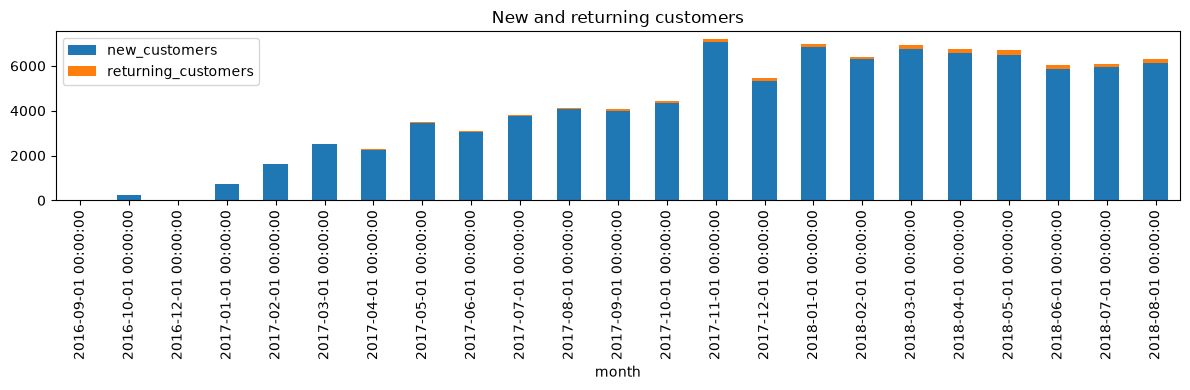

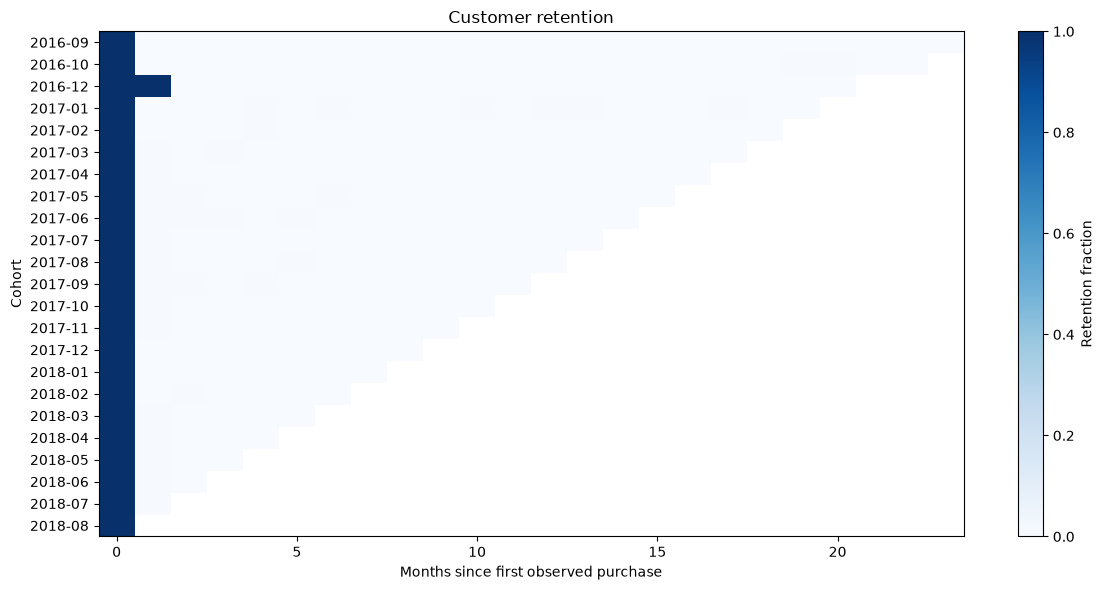

,frequency,last_purchase,monetary,recency_days
count,93358.000000,93358,93357.000000,93358.000000
mean,1.033420,2018-01-04 03:47:36.045363,165.198772,238.478877
min,1.000000,2016-09-15 12:16:38,9.590000,1.000000
25%,1.000000,2017-09-17 18:25:15,63.060000,115.000000
50%,1.000000,2018-01-23 00:12:12.500000,107.780000,219.000000
75%,1.000000,2018-05-07 17:22:34.750000,182.560000,347.000000
max,15.000000,2018-08-29 15:00:37,13664.080000,714.000000
std,0.209097,NaN,226.314579,152.595054


In [3]:
activity = reports['customer_activity']
activity.plot.bar(x='month', y=['new_customers', 'returning_customers'], stacked=True, figsize=(12, 4), title='New and returning customers')
plt.tight_layout()
plt.show()
cohorts = reports['customer_cohorts']
retention = cohorts.pivot(index='cohort_month', columns='month_offset', values='retention_rate')
fig, axis = plt.subplots(figsize=(12, 6))
image = axis.imshow(retention.to_numpy(dtype=float), aspect='auto', vmin=0, vmax=1, cmap='Blues')
axis.set_yticks(range(len(retention)), retention.index.strftime('%Y-%m'))
axis.set(xlabel='Months since first observed purchase', ylabel='Cohort', title='Customer retention')
fig.colorbar(image, ax=axis, label='Retention fraction')
fig.tight_layout()
plt.show()
display(reports['customer_rfm'].describe())

## Logistics, geography, and seller performance

Late deliveries compare calendar dates. Unknown outcomes are excluded from the late-rate denominator. Negative intervals remain visible, matching the cleaning policy. Seller delivery and review summaries count each seller/order once; seller-level order counts cannot be added to obtain a global distinct-order count.

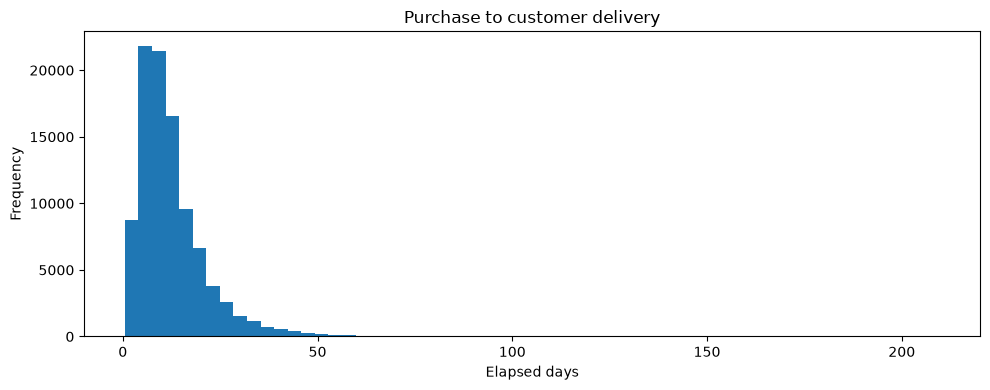

,customer_state,order_count,customer_count,average_delivery_days,late_delivery_rate,known_delivery_outcomes,average_review_score,item_revenue,freight
25,SP,40501,39156,8.761386,0.044945,40494,4.245822,5067633.16,702069.99
18,RJ,12350,11917,15.309438,0.121053,12350,3.965441,1759651.13,295750.44
10,MG,11354,11001,12.008666,0.045711,11354,4.192291,1552481.83,266409.84
22,RS,5345,5168,15.300276,0.060816,5344,4.184907,728897.47,132575.32
17,PR,4923,4769,11.991582,0.040423,4923,4.239796,666063.51,115645.29
23,SC,3546,3449,14.954783,0.082064,3546,4.133561,507012.13,88115.65
4,BA,3256,3158,19.335466,0.121622,3256,3.930629,493584.14,97553.67
6,DF,2080,2019,12.967568,0.056731,2080,4.131401,296498.41,49624.94
7,ES,1995,1928,15.789307,0.107268,1995,4.078720,268643.45,49014.48
8,GO,1957,1895,15.606339,0.065406,1957,4.105858,282836.70,51375.65


,seller_id,units,item_revenue,freight,order_count,average_delivery_days,late_delivery_rate,known_delivery_outcomes,average_review_score,seller_city,seller_state
834,4869f7a5dfa277a7dca6462dcf3b52b2,1148,226987.93,20019.13,1124,15.062424,0.104982,1124,4.150538,guariba,SP
982,53243585a1d6dc2643021fd1853d8905,400,217940.44,12856.58,348,13.432183,0.034483,348,4.193642,lauro de freitas,BA
858,4a3ca9315b744ce9f8e9374361493884,1949,196882.12,34338.31,1772,14.486045,0.097065,1772,3.853394,ibitinga,SP
2903,fa1c13f2614d7b5c4749cbc52fecda94,579,190917.14,9916.36,578,13.354636,0.091696,578,4.372822,sumare,SP
1480,7c67e1448b00f6e969d365cea6b010ab,1355,186570.05,51236.64,973,22.338338,0.09147,973,3.498449,itaquaquecetuba,SP
1504,7e93a43ef30c4f03f38b393420bc753a,322,165981.49,5992.06,319,11.314593,0.047022,319,4.364780,barueri,SP
2543,da8622b14eb17ae2831f4ac5b9dab84a,1548,159816.87,24889.91,1311,11.186555,0.066362,1311,4.180843,piracicaba,SP
1450,7a67c85e85bb2ce8582c35f2203ad736,1155,139658.69,20619.83,1145,11.200218,0.052402,1145,4.276165,sao paulo,SP
188,1025f0e2d44d7041d6cf58b6550e0bfa,1420,138208.56,33716.40,910,12.391190,0.079121,910,4.006652,sao paulo,SP
1758,955fee9216a65b617aa5c0531780ce60,1472,131836.71,24769.77,1261,10.769857,0.061063,1261,4.201117,sao paulo,SP


Negative purchase-to-delivery durations: 0
Unknown late outcomes: 8


In [4]:
orders['delivery_duration_days'].dropna().plot.hist(bins=60, figsize=(10, 4), title='Purchase to customer delivery')
plt.xlabel('Elapsed days')
plt.tight_layout()
plt.show()
display(reports['geography'].sort_values('order_count', ascending=False))
display(reports['seller_performance'].head(15))
print('Negative purchase-to-delivery durations:', int(orders.delivery_duration_days.lt(0).sum()))
print('Unknown late outcomes:', int(orders.is_late.isna().sum()))

## Reviews

Missing reviews are not zero ratings. Comparisons describe associations, not causal effects of delivery. Product and category ratings inherit whole-order reviews and cannot isolate an individual product's quality.

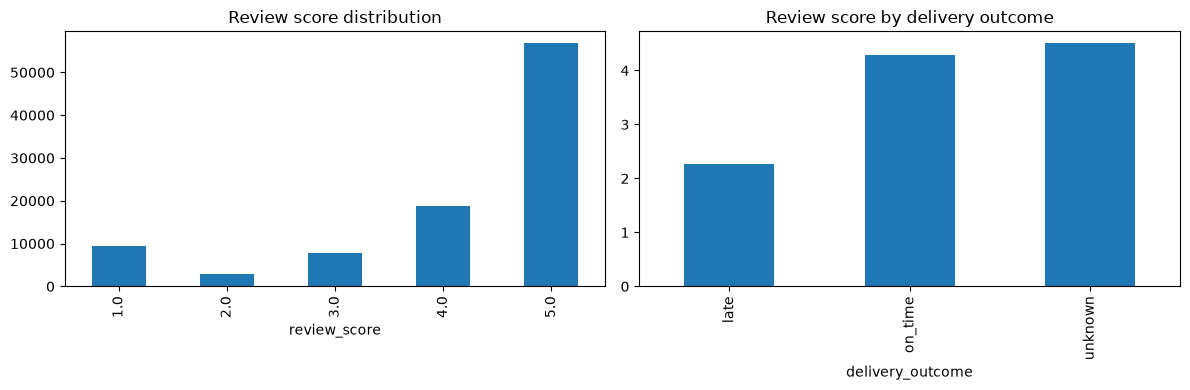

,delivery_outcome,order_count,reviewed_orders,average_review_score,commented_reviews,known_comment_indicators
0,late,6534,6381,2.270491,3835,6381
1,on_time,89936,89443,4.290386,36761,89443
2,unknown,8,8,4.500000,5,8


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
orders['review_score'].value_counts().sort_index().plot.bar(ax=axes[0], title='Review score distribution')
reports['review_delivery'].plot.bar(x='delivery_outcome', y='average_review_score', ax=axes[1], legend=False, title='Review score by delivery outcome')
fig.tight_layout()
plt.show()
display(reports['review_delivery'])

## Reconciliation and exports

Order-grain revenue must agree with selected item rows, product/category reports, and seller reports. The selected cohort's offset-zero retention must equal one. Exported CSVs can also be used in Power BI. SQL validation compares all cleaned values and five business reports with independent Pandas calculations.

In [6]:
import numpy as np

selected_items = data['items'][data['items'].order_id.isin(orders.order_id)]
expected_revenue = selected_items.price.sum()
for name in ['monthly_sales', 'category_sales', 'product_sales', 'seller_performance', 'geography']:
    assert np.isclose(reports[name].item_revenue.sum(), expected_revenue, rtol=0, atol=0.01), name
assert monthly.order_count.sum() == len(orders)
assert (cohorts.loc[cohorts.month_offset == 0, 'retention_rate'] == 1).all()
population = 'all_statuses' if statuses is None else '_'.join(statuses)
output = root / 'data/processed/reports' / population
output.mkdir(parents=True, exist_ok=True)
for name, frame in reports.items():
    frame.to_csv(output / f'{name}.csv', index=False)
print('Selected-population report checks passed; CSVs exported.')
for name in ['database_validation', 'warehouse_validation']:
    path = root / 'data/processed/reports' / f'{name}.csv'
    if path.is_file():
        display(pd.read_csv(path))
    else:
        print(f'{name}: run the database verification command after configuring PostgreSQL.')

Selected-population report checks passed; CSVs exported.


,check,rows,passed
0,geolocation: all values and nulls,19010,True
1,category_translation: all values and nulls,74,True
2,customers: all values and nulls,99441,True
3,products: all values and nulls,32951,True
4,sellers: all values and nulls,3095,True
5,orders: all values and nulls,99441,True
6,order_items: all values and nulls,112650,True
7,order_payments: all values and nulls,103886,True
8,order_reviews: all values and nulls,98673,True
9,order_metrics: every order,99441,True


,check,actual,expected,passed
0,orders,99441.00,99441.00,True
1,items,112650.00,112650.00,True
2,customers,96096.00,96096.00,True
3,products,32951.00,32951.00,True
4,sellers,3095.00,3095.00,True
5,item_value,13591643.70,13591643.70,True
6,freight,2251909.54,2251909.54,True
7,payments,16008872.12,16008872.12,True
8,order_item_value,13591643.70,13591643.70,True
